# LECTURE 17
**Topic:** Zero-Padded Extension; Detection of Sinusoids Using the DFT  
**Textbook References:** Sections 3.7, 3.8

---

## Key Points

- **Zero-padding:** Appending $(M-1)L$ zeros to $s$ (length $L$) gives $y$ of length $N=ML$. The DFT $Y$ contains $S[k]$ at positions $k=0,M,2M,\ldots,(L-1)M$ (every $M$-th entry).
- Zero-padding = **interpolation in frequency** (denser Fourier grid, smoother spectrum).
- The frequency of a complex sinusoid $s[n]=e^{j\Omega_0 n}$ can be estimated to within $2\pi/N$ rad/sample by zero-padding to length $N\gg L$ and locating the spectrum peak.
- $|\langle v^{(\Omega)},s\rangle|=\left|\frac{\sin(L(\Omega-\Omega_0)/2)}{\sin((\Omega-\Omega_0)/2)}\right|$, maximized at $\Omega=\Omega_0$.


---
## Theory and Examples

### 1–3. Zero-Padding and its DFT

Append $N-L$ zeros: $y=[s;\mathbf{0}_{N-L}]$ (length $N$).

For $N=ML$: entry $Y[kM]$ equals $S[k]$, since the $(kM)$-th Fourier sinusoid for length $ML$ equals the $k$-th one for length $L$ (periodically repeated), and the inner product only involves the nonzero part.

**Example** ($L=3$, $N=12$): $y=[a,b,c,0,\ldots,0]^T$ (12 entries):
$$[a,b,c]^T \leftrightarrow [Y_0,Y_4,Y_8]^T$$

### 4. Zero-Padding as Frequency Interpolation

Large $N\gg L$: dense Fourier frequencies, spectrum appears nearly continuous.

### 5–8. Sinusoid Detection

For $s[n]=A\cos(\Omega_0 n+\phi)+\epsilon[n]$ ($n=0:L-1$), with $\Omega_0$ a Fourier frequency:
- Amplitude spectrum has peaks at $k_0$ and $L-k_0$ with magnitude $LA/2$.
- Estimates: $\Omega_0=k_0(2\pi/L)$; $A=2|S[k_0]|/L$; $\phi=\angle S[k_0]$.

When $\Omega_0$ is NOT a Fourier frequency, the spectrum spreads — use zero-padding to refine.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Zero-padding example
L=3; M=4; N=M*L
s=np.array([1.,2.,-1.])
S=np.fft.fft(s)
y=np.concatenate([s,np.zeros(N-L)])
Y=np.fft.fft(y)

print(f's={s}, L={L}')
print(f'S={S.round(4)}')
print(f'Y (N={N}): {Y.round(4)}')
print(f'Every M={M}th entry of Y: {Y[::M].round(4)}')
print(f'Should equal S: {np.allclose(Y[::M],S)}')

# Also [a,b,c,0] (N=4=M*L with M=4/3... actually L=3,N=4,M not integer)
# Let's do the exact example from the lecture: L=3, N=12
y12=np.zeros(12, dtype=complex); y12[:3]=[1.,2.,-1.]
Y12=np.fft.fft(y12)
print(f'\ny=[a,b,c,0,...,0] length 12:')
print(f'Y[0,4,8] = {Y12[[0,4,8]].round(4)}')
print(f'S[0,1,2] = {S.round(4)}')
print(f'Match? {np.allclose(Y12[[0,4,8]], S)}')

s=[ 1.  2. -1.], L=3
S=[2. +0.j     0.5-2.5981j 0.5+2.5981j]
Y (N=12): [ 2.    +0.j      2.2321-0.134j   2.5   -0.866j   2.    -2.j
  0.5   -2.5981j -1.2321-1.866j  -2.    +0.j     -1.2321+1.866j
  0.5   +2.5981j  2.    +2.j      2.5   +0.866j   2.2321+0.134j ]
Every M=4th entry of Y: [2. +0.j     0.5-2.5981j 0.5+2.5981j]
Should equal S: True

y=[a,b,c,0,...,0] length 12:
Y[0,4,8] = [2. +0.j     0.5-2.5981j 0.5+2.5981j]
S[0,1,2] = [2. +0.j     0.5-2.5981j 0.5+2.5981j]
Match? True


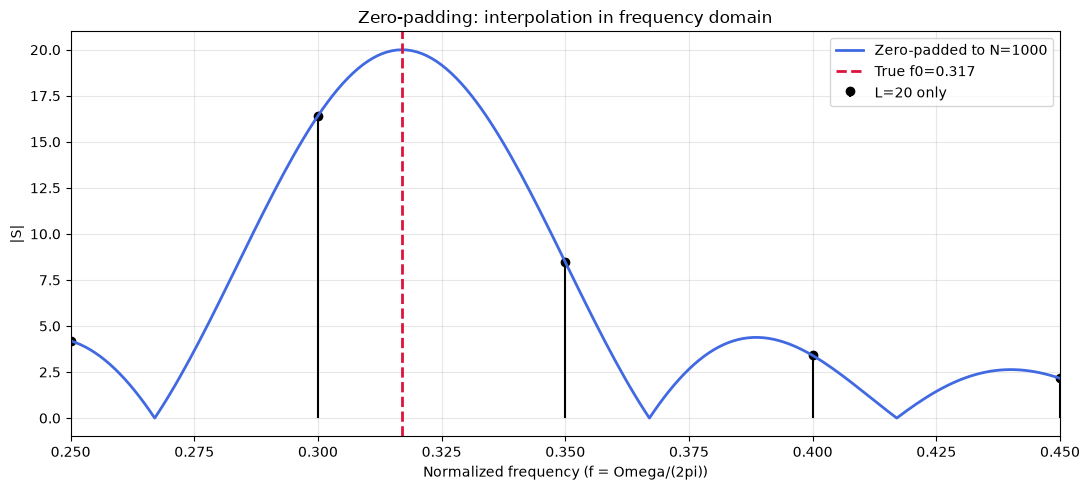

True frequency: 1.9918 rad/sample = 0.3170 * 2pi
Peak in L=20 DFT at k=6, freq=0.3000
Peak in padded DFT at k=317, freq=0.3170


In [2]:
# Zero-padding as frequency interpolation
L=20; omega0=0.317*2*np.pi
n=np.arange(L)
s=np.exp(1j*omega0*n)

fig, ax=plt.subplots(figsize=(11,5))
# Bare DFT (L=20 points)
S20=np.fft.fft(s)
f20=np.arange(L)/L
ax.stem(f20, np.abs(S20), linefmt='k', markerfmt='ko', basefmt=' ', label=f'L={L} only')

# Zero-padded to N=1000
N_big=1000
Y1000=np.fft.fft(s,N_big)
f1000=np.arange(N_big)/N_big
ax.plot(f1000, np.abs(Y1000), 'royalblue', lw=2, label=f'Zero-padded to N={N_big}')
ax.axvline(omega0/(2*np.pi), color='crimson', lw=2, ls='--', label=f'True f0={omega0/(2*np.pi):.3f}')
ax.set_xlabel('Normalized frequency (f = Omega/(2pi))'); ax.set_ylabel('|S|')
ax.set_title('Zero-padding: interpolation in frequency domain')
ax.legend(); ax.grid(True,alpha=0.3); ax.set_xlim(0.25,0.45)
plt.tight_layout(); plt.show()
print(f'True frequency: {omega0:.4f} rad/sample = {omega0/(2*np.pi):.4f} * 2pi')
print(f'Peak in L=20 DFT at k={np.argmax(np.abs(S20))}, freq={np.argmax(np.abs(S20))/L:.4f}')
print(f'Peak in padded DFT at k={np.argmax(np.abs(Y1000))}, freq={np.argmax(np.abs(Y1000))/N_big:.4f}')

---
### 10–12. Geometric Sum Formula for the DFT Response

For the complex sinusoid $s[n]=e^{j\Omega_0 n}$, $n=0:L-1$:
$$\langle v^{(\Omega)},s\rangle = \sum_{n=0}^{L-1}e^{j\Omega_0 n}e^{-j\Omega n} = \sum_{n=0}^{L-1}e^{j(\Omega_0-\Omega)n}$$

Using geometric sum with $z=e^{j(\Omega_0-\Omega)}$:
$$\langle v^{(\Omega)},s\rangle = e^{-j(L-1)(\Omega-\Omega_0)/2}\cdot\frac{\sin(L(\Omega-\Omega_0)/2)}{\sin((\Omega-\Omega_0)/2)}$$

Therefore:
$$|\langle v^{(\Omega)},s\rangle| = \left|\frac{\sin(L(\Omega-\Omega_0)/2)}{\sin((\Omega-\Omega_0)/2)}\right|$$

Maximum value is $L$, achieved at $\Omega=\Omega_0$. This confirms zero-padding finds the true frequency.

> **Insight:** This function (a periodic sinc-like shape) explains the 'spectral leakage' seen when $\Omega_0$ is not a Fourier frequency. Other frequencies get nonzero contributions.


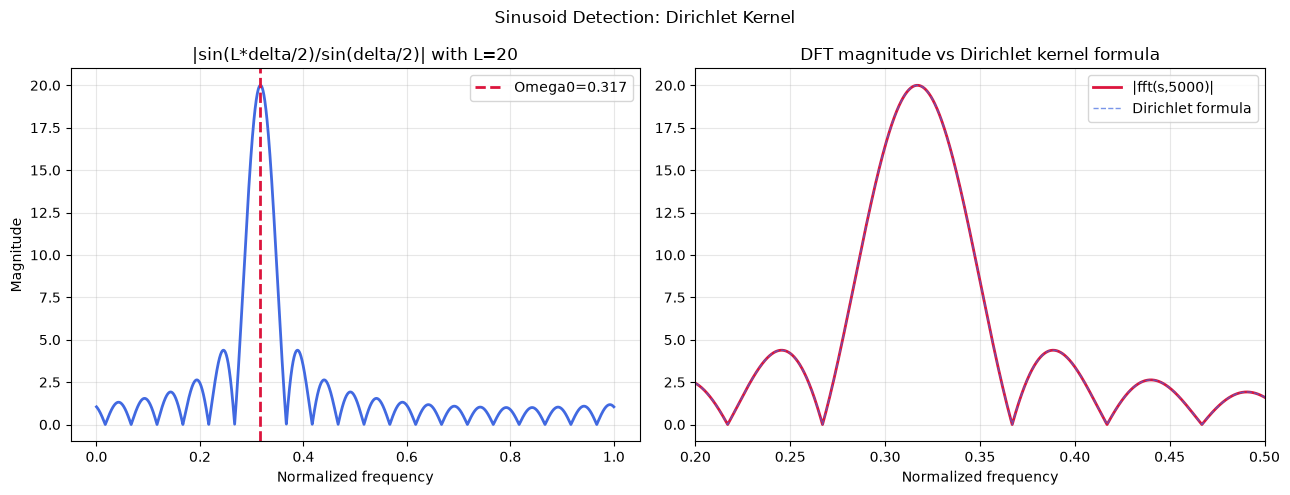

Maximum of kernel = L = 20
Peak of zero-padded DFT: 20.0000 at f=0.3170


In [3]:
# Dirichlet kernel |sin(L*delta/2)/sin(delta/2)|
L=20; omega0=0.317*2*np.pi
omega=np.linspace(0, 2*np.pi, 5000)
delta=omega-omega0
# Handle delta=0
with np.errstate(divide='ignore', invalid='ignore'):
    kernel=np.abs(np.sin(L*delta/2)/np.sin(delta/2))
kernel=np.where(np.isnan(kernel), L, kernel)

fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].plot(omega/(2*np.pi), kernel, 'royalblue', lw=2)
axes[0].axvline(omega0/(2*np.pi), color='crimson', ls='--', lw=2, label=f'Omega0={omega0/(2*np.pi):.3f}')
axes[0].set_title(f'|sin(L*delta/2)/sin(delta/2)| with L={L}')
axes[0].set_xlabel('Normalized frequency'); axes[0].set_ylabel('Magnitude')
axes[0].legend(); axes[0].grid(True,alpha=0.3)

# Compare with actual zero-padded DFT
n_s=np.arange(L); s=np.exp(1j*omega0*n_s)
N_big=5000; Y=np.fft.fft(s,N_big)
f_big=np.arange(N_big)/N_big
axes[1].plot(f_big, np.abs(Y), 'crimson', lw=2, label='|fft(s,5000)|')
# Overlay formula
omega_grid=f_big*2*np.pi
delta_grid=omega_grid-omega0
with np.errstate(divide='ignore', invalid='ignore'):
    kernel_grid=np.abs(np.sin(L*delta_grid/2)/np.sin(delta_grid/2))
kernel_grid=np.where(np.isnan(kernel_grid),L,kernel_grid)
axes[1].plot(f_big, kernel_grid, 'royalblue', lw=1, ls='--', alpha=0.7, label='Dirichlet formula')
axes[1].set_xlim(0.2, 0.5); axes[1].set_xlabel('Normalized frequency')
axes[1].set_title('DFT magnitude vs Dirichlet kernel formula'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.suptitle('Sinusoid Detection: Dirichlet Kernel', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Maximum of kernel = L = {L}')
print(f'Peak of zero-padded DFT: {np.max(np.abs(Y)):.4f} at f={f_big[np.argmax(np.abs(Y))]:.4f}')

=== Sinusoid Detection ===
True: omega0=0.7540 rad/sample, A=3.5, phi=0.7000
Est:  omega_est=0.7540 rad/sample, A_est=3.5497, phi_est=0.7071


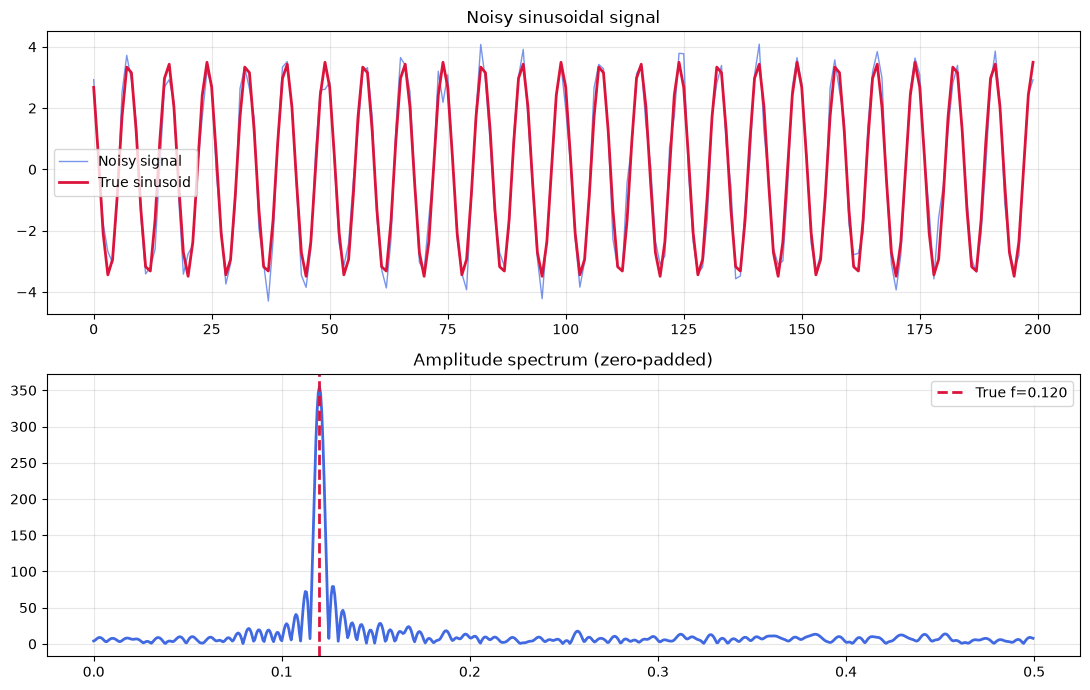

In [4]:
# Practical sinusoid detection: noisy signal
np.random.seed(42)
L=200; fs=1000; Omega0=2*np.pi*120
omega0=Omega0/fs
n=np.arange(L)
A=3.5; phi=0.7
s=A*np.cos(omega0*n+phi)+0.5*np.random.randn(L)

# DFT at L points
S=np.fft.fft(s)
# Zero-padded to 8*L
N_pad=8*L
S_padded=np.fft.fft(s,N_pad)

# Find peak
k_peak=np.argmax(np.abs(S_padded[:N_pad//2]))
omega_est=k_peak*2*np.pi/N_pad
f_est=k_peak/N_pad  # normalized
A_est=2*np.abs(S_padded[k_peak])/L
phi_est=np.angle(S_padded[k_peak])

print('=== Sinusoid Detection ===')
print(f'True: omega0={omega0:.4f} rad/sample, A={A}, phi={phi:.4f}')
print(f'Est:  omega_est={omega_est:.4f} rad/sample, A_est={A_est:.4f}, phi_est={phi_est:.4f}')

fig,axes=plt.subplots(2,1,figsize=(11,7),sharex=False)
axes[0].plot(n,s,'royalblue',lw=1,alpha=0.7,label='Noisy signal')
axes[0].plot(n,A*np.cos(omega0*n+phi),'crimson',lw=2,label='True sinusoid')
axes[0].set_title('Noisy sinusoidal signal'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
f_axis=np.arange(N_pad)/N_pad
axes[1].plot(f_axis[:N_pad//2],np.abs(S_padded[:N_pad//2]),'royalblue',lw=2)
axes[1].axvline(omega0/(2*np.pi),color='crimson',ls='--',lw=2,label=f'True f={omega0/(2*np.pi):.3f}')
axes[1].set_title('Amplitude spectrum (zero-padded)'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## Summary

| Concept | Formula |
|---|---|
| Zero-padding | $y=[s;\mathbf{0}_{N-L}]$ → $Y[kM]=S[k]$ for $N=ML$ |
| Spectral kernel | $|\langle v^{(\Omega)},s\rangle|=|\sin(L\Delta\Omega/2)/\sin(\Delta\Omega/2)|$ |
| Frequency resolution | $2\pi/N$ rad/sample (larger $N$ = finer) |
| Amplitude estimate | $A = 2|S[k_0]|/L$ |
| Phase estimate | $\phi = \angle S[k_0]$ |

### Mistakes to Avoid
1. Zero-padding does **not** add information — it only interpolates (denser grid). Use more **samples** for better frequency resolution.
2. The amplitude estimate formula $2|S[k_0]|/L$ assumes the signal length is $L$ (the original, not the zero-padded length).
3. When $\Omega_0$ is NOT a Fourier frequency, spectral leakage occurs — all DFT bins get contributions.
